# bindcurve basics

This notebook shows the core workflow: build `DoseResponseData`, fit a model, inspect `FitResults`, and plot curves/residuals. The data are synthetic.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import bindcurve as bc

rng = np.random.default_rng(123)

## Create long-form dose-response data

The canonical columns are `compound_id`, `experiment_id`, `concentration`, `replicate_id`, and `response`.

In [2]:
def inhibition_curve(x, ymin=0.0, ymax=100.0, IC50=1.5, hill_slope=-1.1):
    return ymin + (ymax - ymin) / (1.0 + (IC50 / x) ** hill_slope)

rows = []
concentrations = np.logspace(-2, 2, 12)
for experiment_id, ic50_scale in {'exp1': 0.9, 'exp2': 1.0, 'exp3': 1.1}.items():
    for concentration in concentrations:
        mean = inhibition_curve(concentration, IC50=1.5 * ic50_scale)
        for replicate_id in range(1, 4):
            rows.append({
                'compound_id': 'compound_a',
                'experiment_id': experiment_id,
                'concentration': concentration,
                'replicate_id': f'rep{replicate_id}',
                'response': mean + rng.normal(0.0, 2.0),
            })

raw = pd.DataFrame(rows)
raw.head()

,compound_id,experiment_id,concentration,replicate_id,response
0,compound_a,exp1,0.010000,rep1,97.570247
1,compound_a,exp1,0.010000,rep2,98.812917
2,compound_a,exp1,0.010000,rep3,102.124340
3,compound_a,exp1,0.023101,rep1,99.261496
4,compound_a,exp1,0.023101,rep2,100.714009


## Build `DoseResponseData` and fit

By default, bindcurve fits one curve per independent experiment and pools technical replicates at each concentration.

In [3]:
data = bc.DoseResponseData.from_dataframe(raw, concentration_unit='uM', response_unit='percent')

results = bc.fit(
    data,
    model='ic50',
    fixed={'ymin': 0.0, 'ymax': 100.0},
)

results.fits_to_dataframe()

,compound_id,experiment_id,model,success,message,n_data,n_varying_parameters,chisqr,redchi,aic,...,ymin_unit,ymax,ymax_stderr,ymax_unit,IC50,IC50_stderr,IC50_unit,hill_slope,hill_slope_stderr,hill_slope_unit
0,compound_a,exp1,ic50,True,Fit succeeded.,12,2,14.281571,1.428157,6.088760,...,percent,100.0,0.0,percent,1.382342,0.035738,uM,-1.073585,0.026282,None
1,compound_a,exp2,ic50,True,Fit succeeded.,12,2,8.809900,0.880990,0.291633,...,percent,100.0,0.0,percent,1.472060,0.029207,uM,-1.124417,0.022114,None
2,compound_a,exp3,ic50,True,Fit succeeded.,12,2,19.838806,1.983881,10.032799,...,percent,100.0,0.0,percent,1.670297,0.050404,uM,-1.094658,0.031895,None


In [4]:
results.summary_to_dataframe()

,compound_id,parameter,n,mean,sd,sem,unit,summary_scale,geometric_mean,log10_mean,log10_sd
0,compound_a,IC50,3,1.508233,0.147346,0.085070,uM,log10,1.503528,0.177112,0.041852
1,compound_a,hill_slope,3,-1.097553,0.025539,0.014745,NaN,linear,NaN,NaN,NaN
2,compound_a,ymax,3,100.000000,0.000000,0.000000,percent,linear,NaN,NaN,NaN
3,compound_a,ymin,3,0.000000,0.000000,0.000000,percent,linear,NaN,NaN,NaN


## Plot curves and residuals

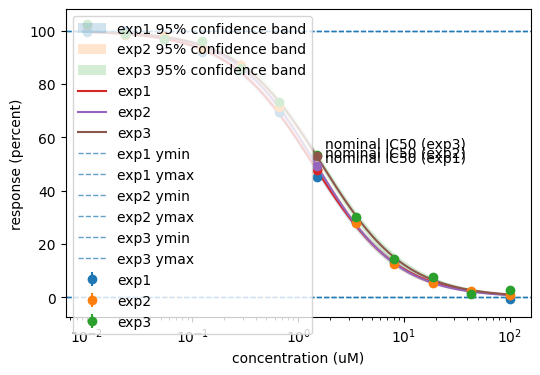

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
bc.plot_curves(
    data,
    results,
    ax=ax,
    confidence_band=True,
    show_asymptotes=True,
    curve_points=[(1.5, 'nominal IC50')],
)
ax.legend()
plt.show()

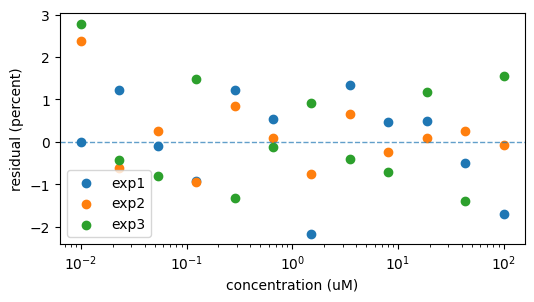

In [6]:
fig, ax = plt.subplots(figsize=(6, 3))
bc.plot_residuals(data, results, ax=ax)
ax.legend()
plt.show()